<a href="https://colab.research.google.com/github/udayanjansai/house_price_prediction_Using_ANN/blob/main/House_Price_Prediction_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential

In [11]:
df=pd.read_csv('/content/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [12]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [13]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [16]:
X=df.drop('median_house_value',axis=1)
y=df['median_house_value']

In [19]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_cols = ['ocean_proximity']
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in categorical_cols]

In [20]:
# Apply OneHotEncoder to the categorical column
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

# Create a DataFrame from the one-hot encoded features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols), index=X.index)

In [21]:
# Combine numerical and encoded categorical features
X_processed = pd.concat([X[numerical_cols], X_encoded_df], axis=1)

In [22]:
# Now apply MinMaxScaler to the processed data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_processed)

# Optionally, convert back to DataFrame if needed for further steps
X_scaled_df = pd.DataFrame(X_scaled, columns=X_processed.columns, index=X_processed.index)
display(X_scaled_df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.0,0.0,0.0,1.0,0.0
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.0,0.0,0.0,1.0,0.0
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.0,0.0,0.0,1.0,0.0
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.0,0.0,0.0,1.0,0.0
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.0,0.0,0.0,1.0,0.0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

## Model Building: ANN with TensorFlow/Keras

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer + 1st hidden layer
    Dense(64, activation='relu'), # 2nd hidden layer
    Dense(32, activation='relu'), # 3rd hidden layer
    Dense(1, activation='linear') # Output layer for regression
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

In [33]:
from tensorflow.keras.optimizers import Adam

# Compile the model with Adam optimizer and Mean Squared Error (MSE) loss
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

### Callbacks for Training: Early Stopping and Learning Rate Decay

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Reduce learning rate when a metric has stopped improving
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', # Monitor validation loss
    factor=0.5,         # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=5,         # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001      # Lower bound on the learning rate
)

# Store callbacks in a list
callbacks = [early_stopping, lr_reducer]

In [35]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print("Model training complete.")

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 38871179264.0000 - val_loss: 11059291136.0000 - learning_rate: 0.0010
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9997124608.0000 - val_loss: 8929295360.0000 - learning_rate: 0.0010
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8699382784.0000 - val_loss: 8112119296.0000 - learning_rate: 0.0010
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7996762624.0000 - val_loss: 7531210240.0000 - learning_rate: 0.0010
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7366437888.0000 - val_loss: 6936799744.0000 - learning_rate: 0.0010
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6722387968.0000 - val_loss: 6343279616.0000 - learning_rate: 0.0010
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6120486912.0000 - val_loss: 5863568384.0000 - learning_rate: 0.0010
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5658903040.0000 - val_loss: 553348

## Model Evaluation: ANN

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred_ann = model.predict(X_test).flatten()

# Calculate evaluation metrics
mae_ann = mean_absolute_error(y_test, y_pred_ann)
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)

print(f"ANN Model MAE: {mae_ann:.2f}")
print(f"ANN Model MSE: {mse_ann:.2f}")
print(f"ANN Model RMSE: {rmse_ann:.2f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN Model MAE: 46083.67
ANN Model MSE: 4376368566.80
ANN Model RMSE: 66154.13


### Predicted vs. Actual House Prices Plot

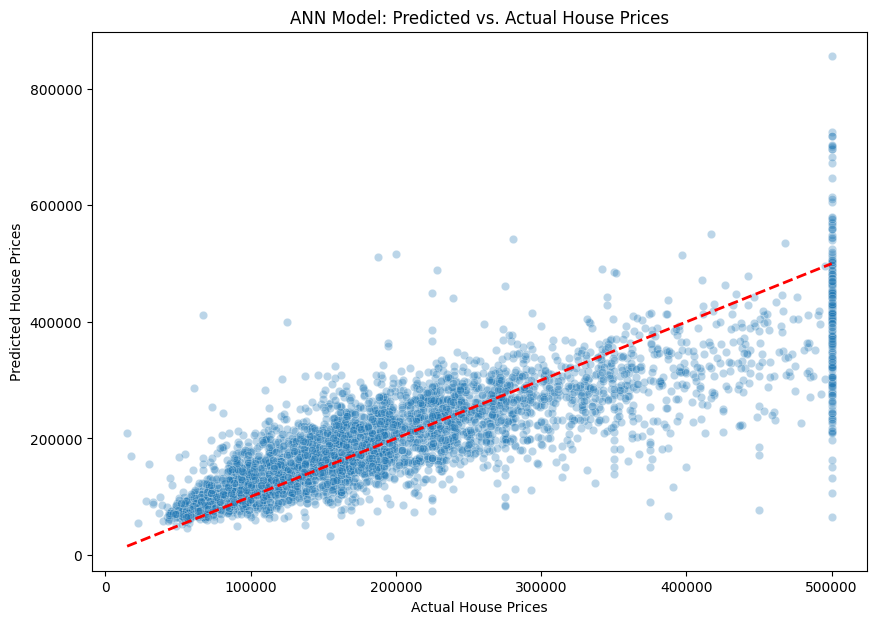

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ann, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect predictions
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("ANN Model: Predicted vs. Actual House Prices")
plt.show()

## Regularization: Lasso Regression

In [42]:
from sklearn.linear_model import Lasso

# Define the Lasso Regression model
lasso_model = Lasso(max_iter=2000) # Increased max_iter for convergence

# Define the hyperparameters to tune for alpha
param_grid_lasso = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Use GridSearchCV for cross-validation to find the best alpha
grid_search_lasso = GridSearchCV(lasso_model, param_grid_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_train, y_train)

# Get the best Lasso model and its parameters
best_lasso_model = grid_search_lasso.best_estimator_
best_lasso_alpha = grid_search_lasso.best_params_['alpha']

print(f"Best Lasso Alpha: {best_lasso_alpha}")

# Evaluate the best Lasso model on the test set
y_pred_lasso = best_lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

print(f"Best Lasso Model MAE: {mae_lasso:.2f}")
print(f"Best Lasso Model MSE: {mse_lasso:.2f}")
print(f"Best Lasso Model RMSE: {rmse_lasso:.2f}")

# Check coefficients that shrink to zero (or close to zero)
print("\nLasso coefficients (some may be zero due to regularization):")
for feature, coef in zip(X_train.columns, best_lasso_model.coef_):
    if abs(coef) < 1e-4: # Consider coefficients close to zero as effectively zero
        print(f"  {feature}: {coef:.4f} (shrunk to zero)")
    else:
        print(f"  {feature}: {coef:.4f}")

Best Lasso Alpha: 1
Best Lasso Model MAE: 50700.67
Best Lasso Model MSE: 4903968630.04
Best Lasso Model RMSE: 70028.34

Lasso coefficients (some may be zero due to regularization):
  longitude: -268843.1513
  latitude: -239097.4758
  housing_median_age: 56211.3424
  total_rooms: -230939.9513
  total_bedrooms: 659277.3519
  population: -1355303.3039
  households: 288529.0580
  median_income: 571807.6068
  ocean_proximity_<1H OCEAN: 3042.0771
  ocean_proximity_INLAND: -36882.5349
  ocean_proximity_ISLAND: 135090.0463
  ocean_proximity_NEAR BAY: -2033.6832
  ocean_proximity_NEAR OCEAN: 6497.6827


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.311e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


### Predicted vs. Actual House Prices Plot (Lasso)

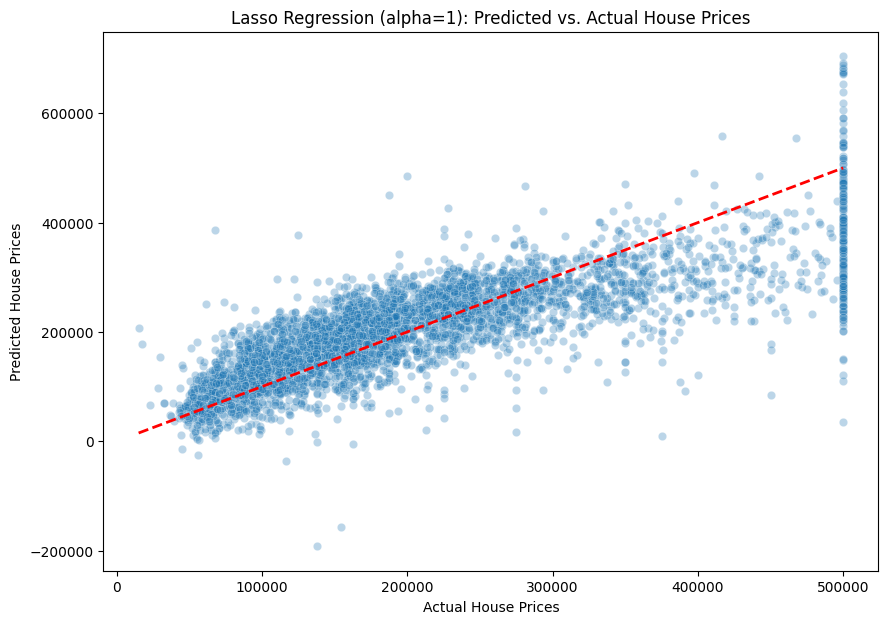

In [43]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Lasso Regression (alpha={best_lasso_alpha}): Predicted vs. Actual House Prices")
plt.show()

## Regularization: Ridge Regression

In [44]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the Ridge Regression model
ridge_model = Ridge()

# Define the hyperparameters to tune for alpha
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Use GridSearchCV for cross-validation to find the best alpha
grid_search_ridge = GridSearchCV(ridge_model, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)

# Get the best Ridge model and its parameters
best_ridge_model = grid_search_ridge.best_estimator_
best_ridge_alpha = grid_search_ridge.best_params_['alpha']

print(f"Best Ridge Alpha: {best_ridge_alpha}")

# Evaluate the best Ridge model on the test set
y_pred_ridge = best_ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print(f"Best Ridge Model MAE: {mae_ridge:.2f}")
print(f"Best Ridge Model MSE: {mse_ridge:.2f}")
print(f"Best Ridge Model RMSE: {rmse_ridge:.2f}")

Best Ridge Alpha: 0.1
Best Ridge Model MAE: 50686.34
Best Ridge Model MSE: 4901199939.51
Best Ridge Model RMSE: 70008.57


### Predicted vs. Actual House Prices Plot (Ridge)

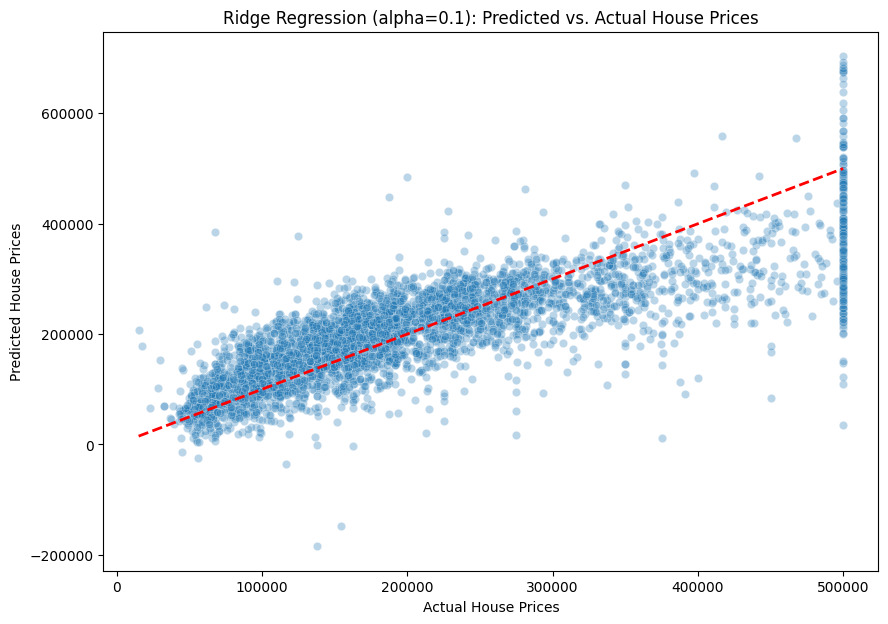

In [45]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Ridge Regression (alpha={best_ridge_alpha}): Predicted vs. Actual House Prices")
plt.show()

## Model Comparison: Performance Summary

In [49]:
import pandas as pd

# Create a dictionary to store the metrics for each model
metrics_data = {
    'Model': ['ANN', 'Ridge', 'Lasso'],
    'MAE': [mae_ann, mae_ridge, mae_lasso],
    'MSE': [mse_ann, mse_ridge, mse_lasso],
    'RMSE': [rmse_ann, rmse_ridge, rmse_lasso]
}

# Create a DataFrame from the metrics data
performance_df = pd.DataFrame(metrics_data)

# Display the performance table
display(performance_df)

,Model,MAE,MSE,RMSE
0,ANN,46083.666164,4.376369e+09,66154.127360
1,Ridge,50686.343254,4.901200e+09,70008.570472
2,Lasso,50700.669113,4.903969e+09,70028.341620


In [48]:
with open('/content/sample_data/README.md', 'r') as f:
    readme_content = f.read()
print(readme_content)

This directory includes a few sample datasets to get you started.

*   `california_housing_data*.csv` is California housing data from the 1990 US
    Census; more information is available at:
    https://docs.google.com/document/d/e/2PACX-1vRhYtsvc5eOR2FWNCwaBiKL6suIOrxJig8LcSBbmCbyYsayia_DvPOOBlXZ4CAlQ5nlDD8kTaIDRwrN/pub

*   `mnist_*.csv` is a small sample of the
    [MNIST database](https://en.wikipedia.org/wiki/MNIST_database), which is
    described at: http://yann.lecun.com/exdb/mnist/

*   `anscombe.json` contains a copy of
    [Anscombe's quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet); it
    was originally described in

    Anscombe, F. J. (1973). 'Graphs in Statistical Analysis'. American
    Statistician. 27 (1): 17-21. JSTOR 2682899.

    and our copy was prepared by the
    [vega_datasets library](https://github.com/altair-viz/vega_datasets/blob/4f67bdaad10f45e3549984e17e1b3088c731503d/vega_datasets/_data/anscombe.json).



### Export Performance Metrics to CSV

In [47]:
performance_df.to_csv('model_performance.csv', index=False)
print("Performance metrics exported to 'model_performance.csv'")

Performance metrics exported to 'model_performance.csv'


# House Price Prediction: ANN vs. Regularized Linear Models

## Project Overview
This project aims to predict house prices using a dataset containing various housing features. We explore and compare the performance of three different machine learning models: an Artificial Neural Network (ANN), Ridge Regression, and Lasso Regression. The goal is to identify which model provides the best generalization on unseen data.

## Dataset
The dataset used is `housing.csv`, which contains information about houses, including `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, `median_house_value` (target variable), and `ocean_proximity`.

## Methodology

### 1. Data Loading and Initial Exploration
- Loaded the dataset into a Pandas DataFrame.
- Performed initial checks for null values and data types (`df.info()`, `df.isnull().sum()`).

### 2. Data Preprocessing
- **Missing Values**: Imputed missing values in `total_bedrooms` with the mean.
- **Duplicate Rows**: Checked for and confirmed no duplicate rows.
- **Feature and Target Split**: Separated the target variable (`median_house_value`) from the features (`X`).
- **Categorical Feature Encoding**: Applied `OneHotEncoder` to the `ocean_proximity` categorical column.
- **Feature Scaling**: Used `MinMaxScaler` to scale all numerical features (including the one-hot encoded features) to a range between 0 and 1.
- **Data Split**: Split the processed data into training and testing sets (80% training, 20% testing).

### 3. Model Building and Training

#### a. Artificial Neural Network (ANN)
- **Architecture**: A Sequential Keras model with an input layer, three dense hidden layers (128, 64, 32 neurons with ReLU activation), and a linear output layer.
- **Compilation**: Compiled with the Adam optimizer (`learning_rate=0.001`) and Mean Squared Error (`mse`) loss function.
- **Callbacks**: Utilized `EarlyStopping` (patience=10) and `ReduceLROnPlateau` (patience=5, factor=0.5) to prevent overfitting and adjust the learning rate during training.
- **Training**: Trained for 100 epochs with a batch size of 32.

#### b. Ridge Regression
- **Model**: Implemented using `sklearn.linear_model.Ridge`.
- **Hyperparameter Tuning**: Used `GridSearchCV` to find the optimal `alpha` (regularization strength) from `[0.01, 0.1, 1, 10, 100]` with 5-fold cross-validation.

#### c. Lasso Regression
- **Model**: Implemented using `sklearn.linear_model.Lasso`.
- **Hyperparameter Tuning**: Used `GridSearchCV` to find the optimal `alpha` from `[0.01, 0.1, 1, 10, 100]` with 5-fold cross-validation.

### 4. Model Evaluation
All models were evaluated on the test set using the following metrics:
- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**

Scatter plots of predicted vs. actual house prices were generated for each model to visualize their performance.

### 5. Model Comparison
A summary table (`performance_df.csv`) was created to compare the MAE, MSE, and RMSE values across all three models.

## Key Findings
Based on the evaluation metrics:
- **ANN Model:** MAE: 46083.67, MSE: 4.376369e+09, RMSE: 66154.13
- **Ridge Model:** MAE: 50686.34, MSE: 4.901200e+09, RMSE: 70008.57
- **Lasso Model:** MAE: 50700.67, MSE: 4.903969e+09, RMSE: 70028.34

The **Artificial Neural Network (ANN)** model demonstrated the best generalization performance on the test set, achieving the lowest MAE, MSE, and RMSE among the three models.

## How to Run the Notebook
1.  **Open in Google Colab**: Upload the `.ipynb` notebook file to Google Colab.
2.  **Ensure Data is Present**: Make sure `housing.csv` is uploaded to the `/content/` directory or update the data loading path accordingly.
3.  **Run All Cells**: Execute all cells in the notebook sequentially.

## Dependencies
Key libraries used in this project include:
- `pandas`
- `numpy`
- `scikit-learn` (for preprocessing and linear models)
- `tensorflow` (for the ANN model)
- `matplotlib` (for plotting)
- `seaborn` (for plotting)

These libraries can typically be installed via `pip` if not already available in your environment:
```bash
pip install pandas numpy scikit-learn tensorflow matplotlib seaborn
```